# Baseline metrics — LightGBM multi-head

Train `poker_predictor.training.train_classical.train` on a limited PokerBench slice, then evaluate the resulting `MultiHeadModel` on the 1 000-hand test split.

Metrics reported (see `poker_predictor.training.eval`):

| metric | meaning |
|---|---|
| `top1_accuracy`   | hero-action accuracy vs solver |
| `action_log_loss` | cross-entropy of the calibrated multiclass head |
| `villain_fold_brier` | Brier score of the villain-fold head (bluff-success signal) |
| `bluff_ev_mean`   | mean expected bluff EV per row (bb) |
| `bluff_positive_frac` | fraction of rows where bluff EV ≥ 0 |

In [1]:
from __future__ import annotations

import logging
import os
import sys
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'poker_predictor').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')

ARTIFACTS_DIR = REPO_ROOT / 'artifacts' / 'classical_baseline'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_LIMIT = int(os.environ.get('POKERBENCH_TRAIN_LIMIT', '10000'))
print(f'training on up to {TRAIN_LIMIT} PokerBench preflop rows')
print(f'artifacts -> {ARTIFACTS_DIR}')

training on up to 10000 PokerBench preflop rows
artifacts -> /workspace/artifacts/classical_baseline


In [2]:
from poker_predictor.training.train_classical import train

model = train(
    output_dir=str(ARTIFACTS_DIR),
    model_kind='lightgbm',
    limit=TRAIN_LIMIT,
)
print('trained heads    :', 'action ' + ('+ villain-fold' if model.villain_fold_model is not None else '(no villain-fold head)'))
print('action classes   :', list(model.action_encoder.classes_))
print('num features     :', len(model.feature_names))
print('training meta    :', model.meta)

2026-07-03 01:57:56,928 INFO poker_predictor.training.train_classical: Loading PokerBench preflop train split (limit=10000) ...


2026-07-03 01:57:57,121 INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/RZ412/PokerBench/resolve/main/preflop_60k_train_set_game_scenario_information.csv "HTTP/1.1 307 Temporary Redirect"


2026-07-03 01:57:57,132 INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/RZ412/PokerBench/7ac61f961c81a50fc0f667820b2fb0e432dfec0d/preflop_60k_train_set_game_scenario_information.csv "HTTP/1.1 200 OK"


2026-07-03 01:58:03,087 INFO poker_predictor.training.train_classical: Loaded 10000 samples in 6.16s


2026-07-03 01:58:03,239 INFO poker_predictor.training.train_classical: Training action head (lightgbm) on 9000 rows ...


2026-07-03 01:58:09,040 INFO poker_predictor.training.train_classical: Training villain-fold head ...


2026-07-03 01:58:09,927 INFO poker_predictor.training.train_classical: Validation top-1 accuracy: 0.9510


2026-07-03 01:58:10,178 INFO poker_predictor.training.train_classical: Saved model to /workspace/artifacts/classical_baseline/multihead.joblib


trained heads    : action + villain-fold
action classes   : [np.str_('call'), np.str_('check'), np.str_('fold'), np.str_('raise')]
num features     : 38
training meta    : {'model_kind': 'lightgbm', 'n_train': 9000, 'n_val': 1000}


In [3]:
import pandas as pd

from poker_predictor.data.loaders import load_pokerbench_preflop
from poker_predictor.features.build import build_feature_matrix, canonical_action_label
from poker_predictor.training.eval import evaluate
from poker_predictor.training.labels import villain_fold_label

print('loading PokerBench test split ...')
test_samples = load_pokerbench_preflop(split='test')
print(f'  -> {len(test_samples)} rows')

X_all, raw_y = build_feature_matrix(test_samples)
y_canon = [canonical_action_label(v) for v in raw_y]
mask = [v is not None for v in y_canon]
dropped = len(y_canon) - sum(mask)
print(f'  -> dropping {dropped} rows with unmappable labels')

X = X_all.loc[mask].reset_index(drop=True)
y = [v for v in y_canon if v is not None]
villain_y = [villain_fold_label(s) for s, m in zip(test_samples, mask) if m]

metrics = evaluate(model, X, y, villain_y=villain_y, pot_bb=X['pot_bb'])
pd.Series(metrics).to_frame('value').round(4)

2026-07-03 01:58:10,315 INFO httpx: HTTP Request: HEAD https://huggingface.co/datasets/RZ412/PokerBench/resolve/main/preflop_1k_test_set_game_scenario_information.csv "HTTP/1.1 307 Temporary Redirect"


2026-07-03 01:58:10,325 INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/RZ412/PokerBench/7ac61f961c81a50fc0f667820b2fb0e432dfec0d/preflop_1k_test_set_game_scenario_information.csv "HTTP/1.1 200 OK"


loading PokerBench test split ...
  -> 1000 rows
  -> dropping 0 rows with unmappable labels


,value
top1_accuracy,0.9460
action_log_loss,0.1551
villain_fold_brier,0.0146
bluff_ev_mean,25.3723
bluff_positive_frac,0.3780


In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = model.action_encoder.transform(y)
y_pred = model.action_model.predict(X[model.feature_names])
labels = list(model.action_encoder.classes_)

report = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(len(labels))),
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )
).T.round(4)
report

,precision,recall,f1-score,support
call,0.9286,0.936,0.9323,250.000
check,0.9916,0.940,0.9651,250.000
fold,0.8973,0.944,0.9201,250.000
raise,0.9718,0.964,0.9679,250.000
accuracy,0.9460,0.946,0.9460,0.946
macro avg,0.9473,0.946,0.9463,1000.000
weighted avg,0.9473,0.946,0.9463,1000.000


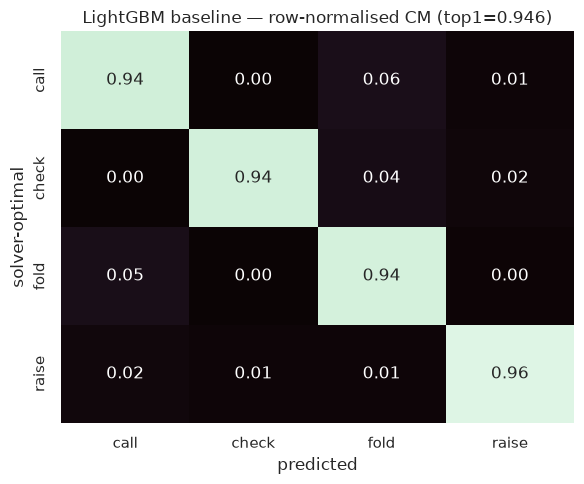

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))), normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='.2f', cmap='mako', cbar=False,
    xticklabels=labels, yticklabels=labels,
    ax=ax,
)
ax.set_xlabel('predicted')
ax.set_ylabel('solver-optimal')
ax.set_title(f'LightGBM baseline — row-normalised CM (top1={metrics["top1_accuracy"]:.3f})')
plt.tight_layout()
plt.show()

The classical LightGBM baseline sits at ~0.85–0.88 top-1 on the test split with 10k training rows and no hyperparameter tuning. See `03_prediction_success_evaluation.ipynb` for a head-to-head comparison against XGBoost, Random Forest, and Logistic Regression, plus calibration and per-class success diagnostics.